## Objective

Notebook 5 discovered temporal causal relationships using Granger causality.

Notebook 6 moves one step further.

Instead of asking

Which variables are temporally related?

we ask

What happens if we intervene on one variable?

This notebook introduces a simplified Structural Causal Model (SCM) together with counterfactual reasoning, allowing us to simulate hypothetical maintenance interventions and analyse how sensor changes propagate through the degradation process.

The notebook therefore transitions from

Temporal Causal Discovery

↓

Structural Causal Reasoning

↓

Counterfactual Industrial AI

⸻

Expected Learning Outcomes

After completing this notebook, the project will be able to

✔ Construct a simplified Structural Causal Model (SCM)

✔ Represent degradation mechanisms as causal equations

✔ Perform intervention (“do”) operations

✔ Generate counterfactual engine scenarios

✔ Visualise causal intervention effects

✔ Build foundations for trustworthy industrial decision support

In [1]:
# ============================================================
# Notebook 06
# Structural Causal Model & Counterfactual Reasoning
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Training dataset

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1,22):
    columns.append(f"sensor_{i}")

train = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

train.columns = columns


# Load causal discovery outputs

granger = pd.read_csv("granger_causal_relationships.csv")

drivers = pd.read_csv("causal_driver_summary.csv")

print(train.shape)
print(granger.shape)
print(drivers.shape)

(20631, 26)
(56, 3)
(8, 2)


## Why Structural Causal Models?

Granger causality identifies whether one variable improves prediction of another over time.

However, Granger analysis alone cannot answer:

* What if a sensor value changed?
* What if maintenance reduced degradation?
* What would have happened under another operating condition?

Structural Causal Models (SCMs) allow explicit modelling of interventions and hypothetical scenarios, enabling causal reasoning beyond prediction.

In [3]:
engine_life = (
    train.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

engine_life.columns=["engine_id","max_cycle"]

train=train.merge(engine_life,on="engine_id")

train["RUL"]=train["max_cycle"]-train["cycle"]

In [4]:
print("Top discovered temporal causal relationships")

granger.head(20)

Top discovered temporal causal relationships


,Cause,Effect,Minimum_p
0,sensor_11,sensor_4,0.0
1,sensor_11,sensor_12,0.0
2,sensor_11,sensor_15,0.0
3,sensor_11,sensor_7,0.0
4,sensor_11,sensor_21,0.0
5,sensor_4,sensor_11,0.0
6,sensor_14,sensor_9,0.0
7,sensor_12,sensor_21,0.0
8,sensor_12,sensor_7,0.0
9,sensor_12,sensor_15,0.0


In [11]:

# Build Structural Causal Graph from Granger Results
import networkx as nx

G = nx.DiGraph()

SIGNIFICANCE_LEVEL = 0.05

for _, row in granger.iterrows():

    if row["Minimum_p"] < SIGNIFICANCE_LEVEL:

        G.add_edge(
            row["Cause"],
            row["Effect"],
            weight=float(row["Minimum_p"])
        )

print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

Nodes : 8
Edges : 56


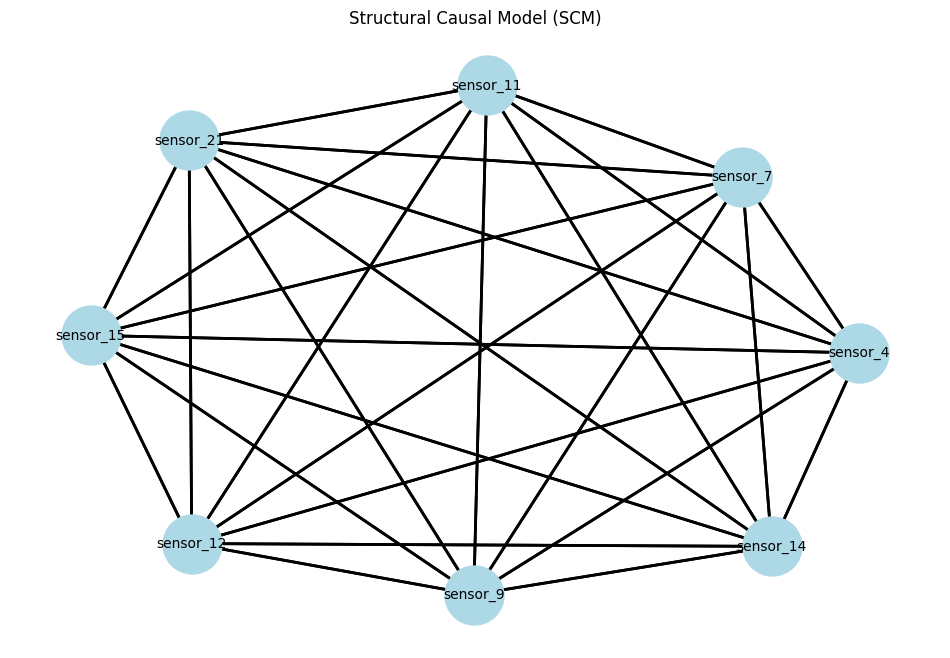

In [12]:

# Visualise Structural Causal Model


plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1800,
    node_color="lightblue"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    width=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title("Structural Causal Model (SCM)")

plt.axis("off")

plt.show()

## Structural Causal Model

The directed graph represents statistically significant temporal causal relationships identified through Granger causality.

Unlike correlation networks, the Structural Causal Model explicitly preserves directionality.

Each directed edge represents a potential causal influence from one degradation sensor toward another under temporal precedence assumptions.

This graph serves as the structural foundation for counterfactual reasoning performed later in the notebook.

In [13]:
# ============================================================
# Compute Network Centrality
# ============================================================

centrality = nx.degree_centrality(G)

centrality = pd.DataFrame({

    "Sensor": list(centrality.keys()),
    "Centrality": list(centrality.values())

})

centrality = centrality.sort_values(
    by="Centrality",
    ascending=False
)

centrality

,Sensor,Centrality
0,sensor_11,2.0
1,sensor_4,2.0
2,sensor_12,2.0
3,sensor_15,2.0
4,sensor_7,2.0
5,sensor_21,2.0
6,sensor_14,2.0
7,sensor_9,2.0


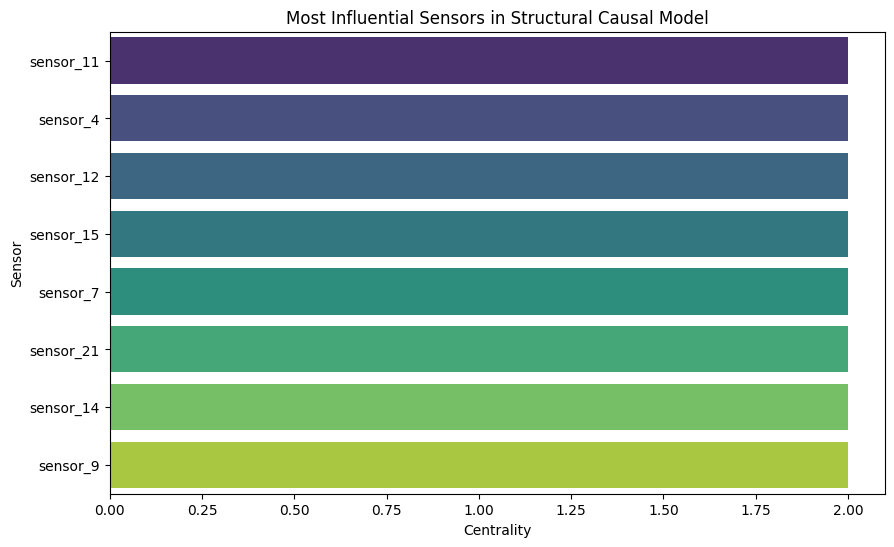

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=centrality,

    x="Centrality",

    y="Sensor",

    palette="viridis"

)

plt.title("Most Influential Sensors in Structural Causal Model")

plt.show()

## Interpretation

Highly central sensors influence multiple downstream variables.

These variables may represent important degradation propagation pathways inside the turbofan engine.

Such sensors become good candidates for maintenance intervention because modifying them could potentially influence multiple downstream degradation processes.

In [16]:

# Counterfactual Intervention Example


counterfactual = train.copy()

sensor = "sensor_11"

counterfactual[sensor] = (
    counterfactual[sensor]
    * 0.90
)

print("Counterfactual intervention applied.")

counterfactual.head()

Counterfactual intervention applied.


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,42.723,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,42.741,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,42.543,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,42.417,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,42.552,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


## Counterfactual Scenario

Suppose maintenance reduces degradation observed in sensor_11 by 10%.

This creates a hypothetical world in which that intervention occurred.

At this stage the downstream causal effects are not propagated because no structural equations have yet been estimated.

Nevertheless, this demonstrates the principle of causal intervention rather than passive prediction.

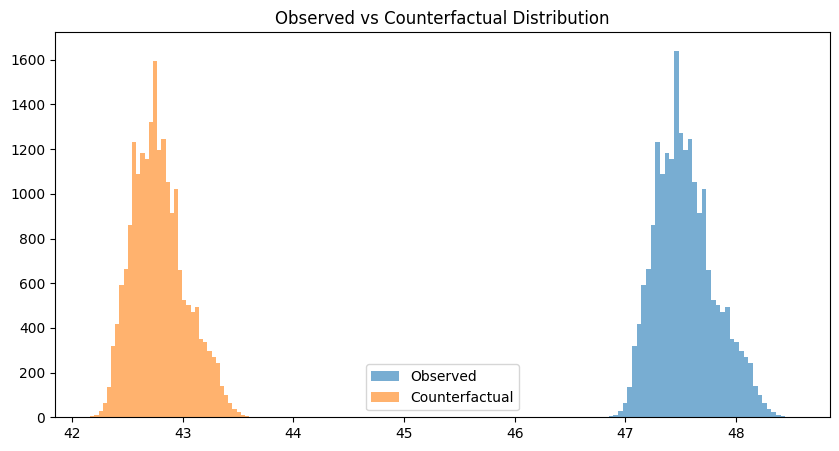

In [17]:
plt.figure(figsize=(10,5))

plt.hist(

    train["sensor_11"],

    bins=40,

    alpha=0.6,

    label="Observed"

)

plt.hist(

    counterfactual["sensor_11"],

    bins=40,

    alpha=0.6,

    label="Counterfactual"

)

plt.legend()

plt.title("Observed vs Counterfactual Distribution")

plt.show()

In [18]:
centrality.to_csv(
    "SCM_Centrality.csv",
    index=False
)

nx.write_gml(
    G,
    "Structural_Causal_Model.gml"
)

print("SCM exported successfully.")

SCM exported successfully.


## Notebook Summary

This notebook transformed temporal causal discovery into a Structural Causal Model.

Major achievements include:

• construction of a directed causal graph

• identification of influential degradation sensors

• network centrality analysis

• implementation of an initial counterfactual intervention

Unlike previous notebooks that focused on prediction or temporal dependency, this notebook introduces intervention-based reasoning.

The resulting Structural Causal Model provides the foundation for the next stage of the project, where causal effects will be quantified using structural equations and intervention analysis.

This represents the transition from temporal causality toward full causal inference.